### **K-means (평균을 이용한 군집화)**


- k개 그룹으로 자동 분류하는 비지도 학습 알고리즘
- 종속 변수가 존재하지 않는 데이터에서 유사한 데이터끼리 모음
- 서로 가까운 데이터는 같은 그룹으로 묶어서 그룹화
- 그룹의 중심점을 반복적으로 계산(중심점의 이동)하여 군집을 형성

- 작업 순서
    - 초기의 중심점(k개)을 선택
    - 각각의 데이터들과 중심점 사이의 거리를 확인
    - 가까운 거리를 중심점으로 할당
    - 각 군집의 평균을 구해서 새로운 중심점들을 설정
    - 중심점의 변화가 거의 없을 때까지 반복 실행

- 장점
    - 빠르고 단순하여 대용량의 데이터에서 적합

- 단점
    - 군집의 수를 미리 알고 작성해야한다.
    - 이상치에 굉장히 민감

- **parameter**
    - `n_clusters`
        - default : 8
        - 군집의 개수를 지정
        - 너무 작거나 큰 경우에는 성능 저하 가능
    
    - `init`
        - default : 'k_means++'
        - 초기의 중심점을 설정하는 방법
        - 기본값을 사용하면 빠르고 안정적
        - 'random' : 중심점을 무작위하게 설정
    
    - `n_init`
        - default : 'auto'
        - 초기화 횟수
        - 초기화하여 여러번의 시를 통해 최적의 결과를 만드는 방법
    
    - `max_iter`
        - default : 300
        - 한번의 실행에서 최대의 반복 횟수
    
    - `tol`
        - default : 1e-4
        - 중심점 이동의 변화량이 이 값보다 작은 경우에는 수렴
    
    - `algorithm`
        - default : `lloyd`
        - `elkan` : 속도 향상 (밀집 데이터에서 유리)

- **속성**
    - `cluster_center`
        - 각 군집의 중심점 좌표
    - `labels_`
        - 각 데이터의 군집의 번호 출력
    - `inertia_`
        - 군집 내의 거리 제곱합
        - 작을수록 군집이 응집되어있음
    - `n_iter_`
        - 마지막 반복에서의 수행 횟수(중심점 이동 횟수)
    
- **메서드**
    - `fit(X)`
        - 모델의 학습
    - `predict()`
        - 새로운 데이터를 이용하여 군집화
    - `transform()`
        - 각 데이터와 각 중심점간의 거리를 행렬로 변환하여 출력
    - `score()`
        - _inertia 값을 반환
    - `get_params()` / `set_params()`

- **검증 방법**
    - `inertia_`
        - 군집 내의 거리 제곱합(작을수록 응집)
    - `silhouette_score`
        - 응집도 + 분리도의 종합점수 (1에 가까울수록 좋음)
    - `calinski_Harabasz_score`
        - 군집 간의 분산 / 군집 내의 분산 비율 (높을수록 좋음)
    - `davies_Bouldin_score`
        - 군집 간의 유사도 평균 (낮을수록 좋음)
    - `adjusted_rand_score`
        - 실제의 라벨과 군집의 일치도 (1=일치, 0=불일치)

### **코드**

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

In [3]:
iris = pd.read_csv('../csv/iris.csv')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [4]:
X = iris.drop('species', axis = 1)
y = iris['species']

In [5]:
# 군집화는 일반적으로 Scaler를 사용

X_std = StandardScaler().fit_transform(X)

In [6]:
# Kmeans 객체 생성

model = KMeans(
    n_clusters = 3,
    random_state = 42,
    n_init = 10
)

In [7]:
model.fit(X_std)
labels = model.predict(X_std)

In [8]:
# 검증 지표 (군집이 얼마나 잘 되었는가?)
inertia = model.inertia_
silhouette = silhouette_score(X_std, labels)
chs = calinski_harabasz_score(X_std, labels)
dbs = davies_bouldin_score(X_std, labels)

# 실제 라벨과의 계산
ari = adjusted_rand_score(y, labels)

print('inertia: ', round(inertia, 3))
print('silhouette: ', round(silhouette, 3))
print('calinski: ', round(chs, 3))
print('davies: ', round(dbs, 3))
print('ARI: ', round(ari, 3))

inertia:  139.82
silhouette:  0.46
calinski:  241.904
davies:  0.834
ARI:  0.62


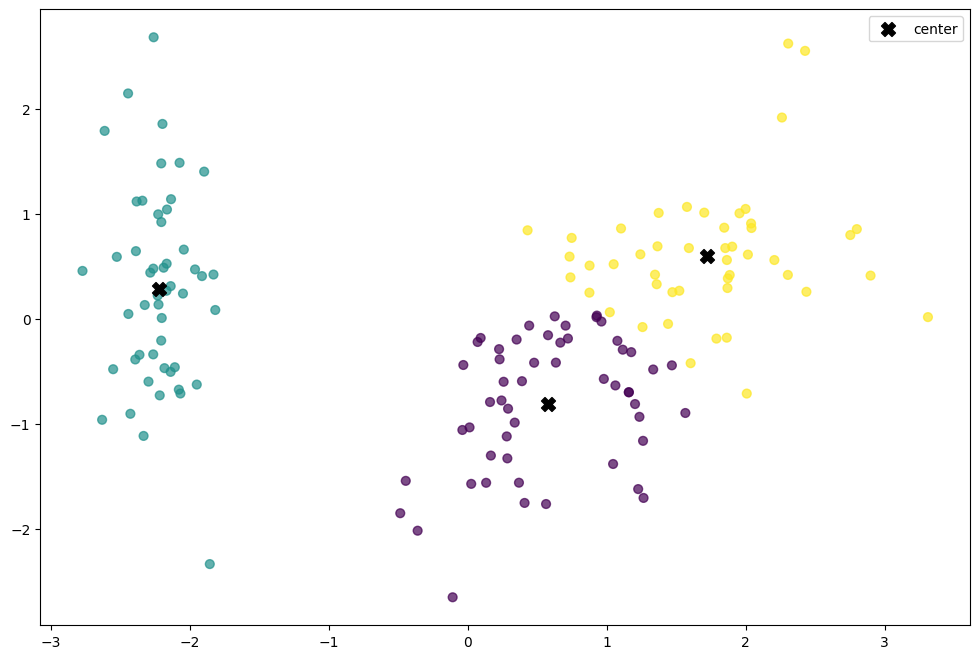

In [9]:
# 군집의 상황을 2차원 그래프로 시각화 → 차원 축소
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_std)

# pca를 이용해서, 중심점을 2차원으로 축소
center_pca = pca.transform(model.cluster_centers_)

plt.figure(figsize = (12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels, cmap = 'viridis', s = 40, alpha = 0.7)
plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, marker = 'X', label='center')
plt.legend()
plt.show()

In [10]:
# body 군집

df = pd.read_csv('../data/bodyPerformance.csv')
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [11]:
from sklearn.preprocessing import LabelEncoder

In [13]:
# labelencoding 하려는 column들이 다수 존재한다면 → object형 column의 이름들을 모두 추출

obj_cols = df.select_dtypes('object').columns

C:\Users\hkssn\AppData\Local\Temp\ipykernel_7540\2097600545.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes('object').columns


In [14]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [15]:
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2


In [16]:
# 범주형 데이터들을 제외한 독립 변수를 생성

X = df.drop(['gender', 'class'], axis = 1)
y1 = df['class']
y2 = df['gender']

In [17]:
X_std = StandardScaler().fit_transform(X)

In [19]:
# 검증 지표(실루엣 점수) 확인
# 군집의 개수는 2~10까지 확인
# 검증 지표들을 하나의 리스트에 저장

rows = []

for k in range(2, 11):
    # k → 군집의 개수
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    pred = km.fit_predict(X_std)
    # 검증 지표
    iner = km.inertia_
    sil = silhouette_score(X_std, pred)

    row = {
        'K': k,
        'inertia': iner,
        'silhouette': sil
    }

    rows.append(row)

In [20]:
scores = pd.DataFrame(rows)
scores.sort_values('silhouette', ascending = False)

,K,inertia,silhouette
0,2,92209.116383,0.285521
1,3,80763.188170,0.212558
2,4,71405.576102,0.200472
4,6,62240.243243,0.176855
3,5,66252.724674,0.172895
5,7,59232.077009,0.159284
6,8,57055.449406,0.150871
7,9,55019.760843,0.143290
8,10,53510.303369,0.134315


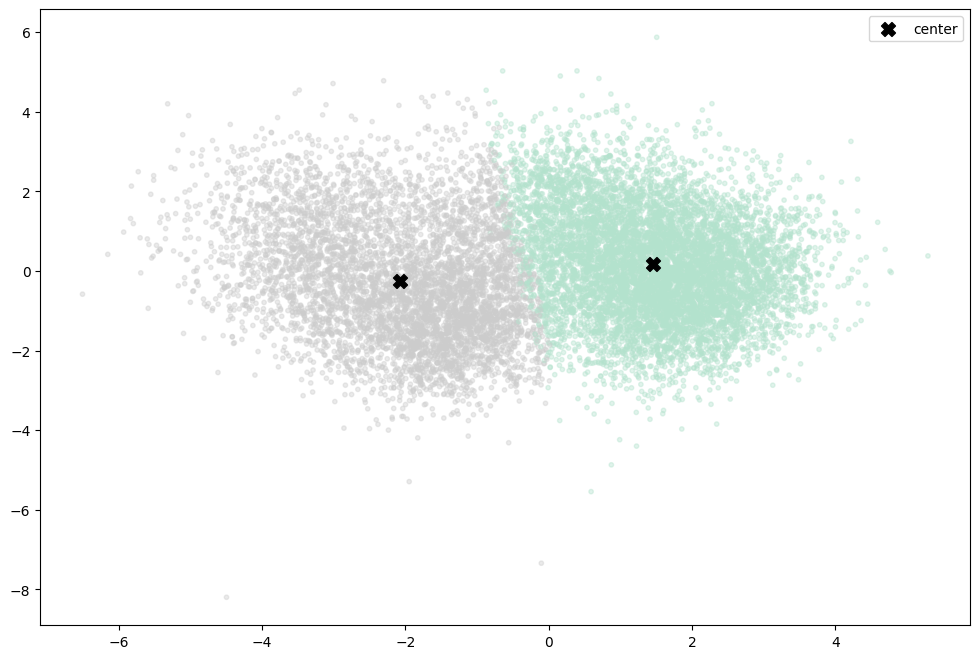

In [39]:
# 군집의 개수가 2인 경우 중심점과 차원 축소로 2차원 데이터의 분포도

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

km_best = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_std)

labels_best = km_best.labels_
center_best = km_best.cluster_centers_
center_pca = pca.transform(center_best)

plt.figure(figsize=(12,8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels_best, s = 10, cmap='Pastel2', alpha = 0.4)
plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, marker = 'X', label='center')

plt.legend()
plt.show()

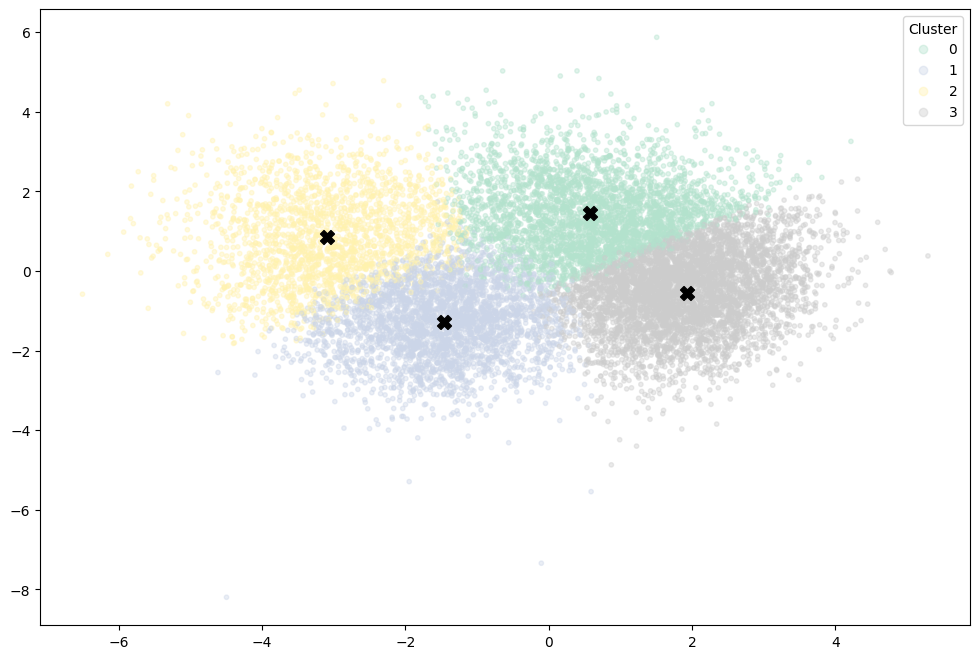

In [41]:
# 군집의 개수가 4인 경우 중심점과 차원 축소로 2차원 데이터의 분포도

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

km_best = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_std)

labels_best = km_best.labels_
center_best = km_best.cluster_centers_
center_pca = pca.transform(center_best)

plt.figure(figsize=(12,8))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels_best, s = 10, cmap='Pastel2', alpha = 0.4)
plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, marker = 'X', label='center')

plt.legend(*sc.legend_elements(), title='Cluster')
plt.show()

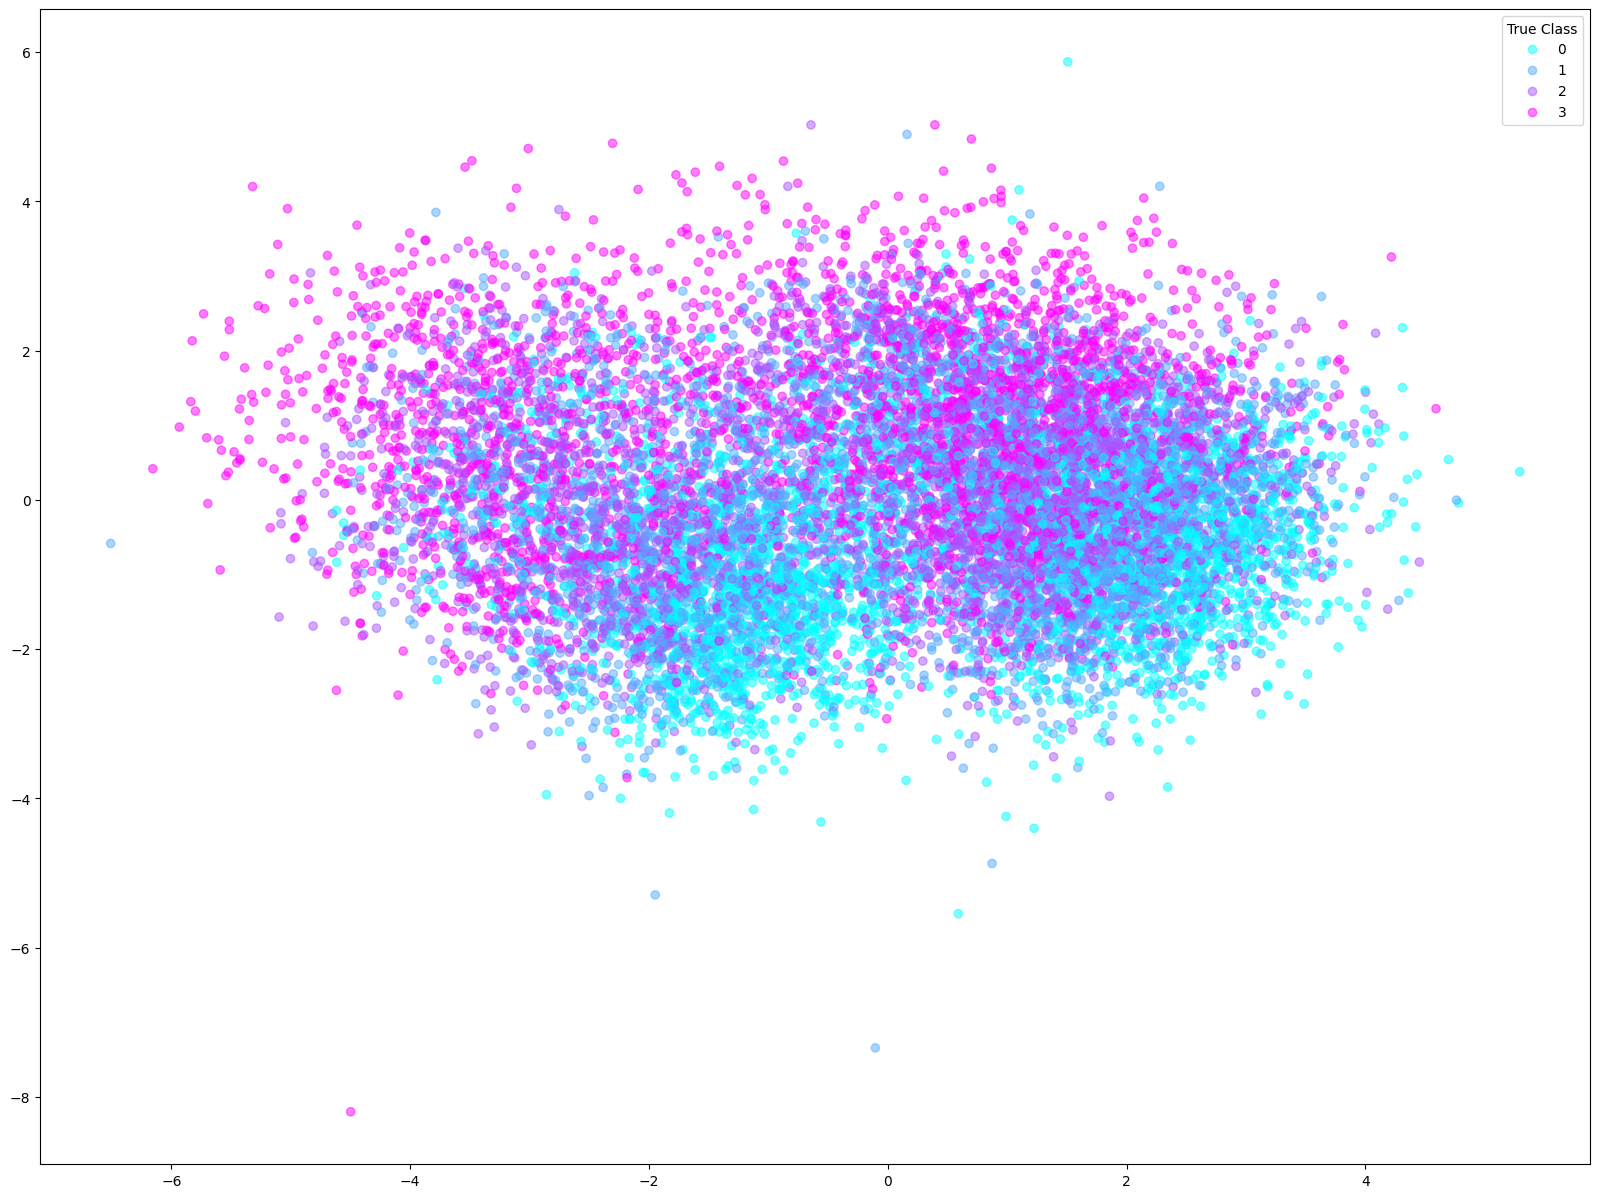

In [51]:
# class column별 데이터의 분포를 확인
plt.figure(figsize = (20, 15))

sc_class = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c = y1, cmap='cool', alpha = 0.5
)

plt.legend(*sc_class.legend_elements(), title = 'True Class')
plt.show()

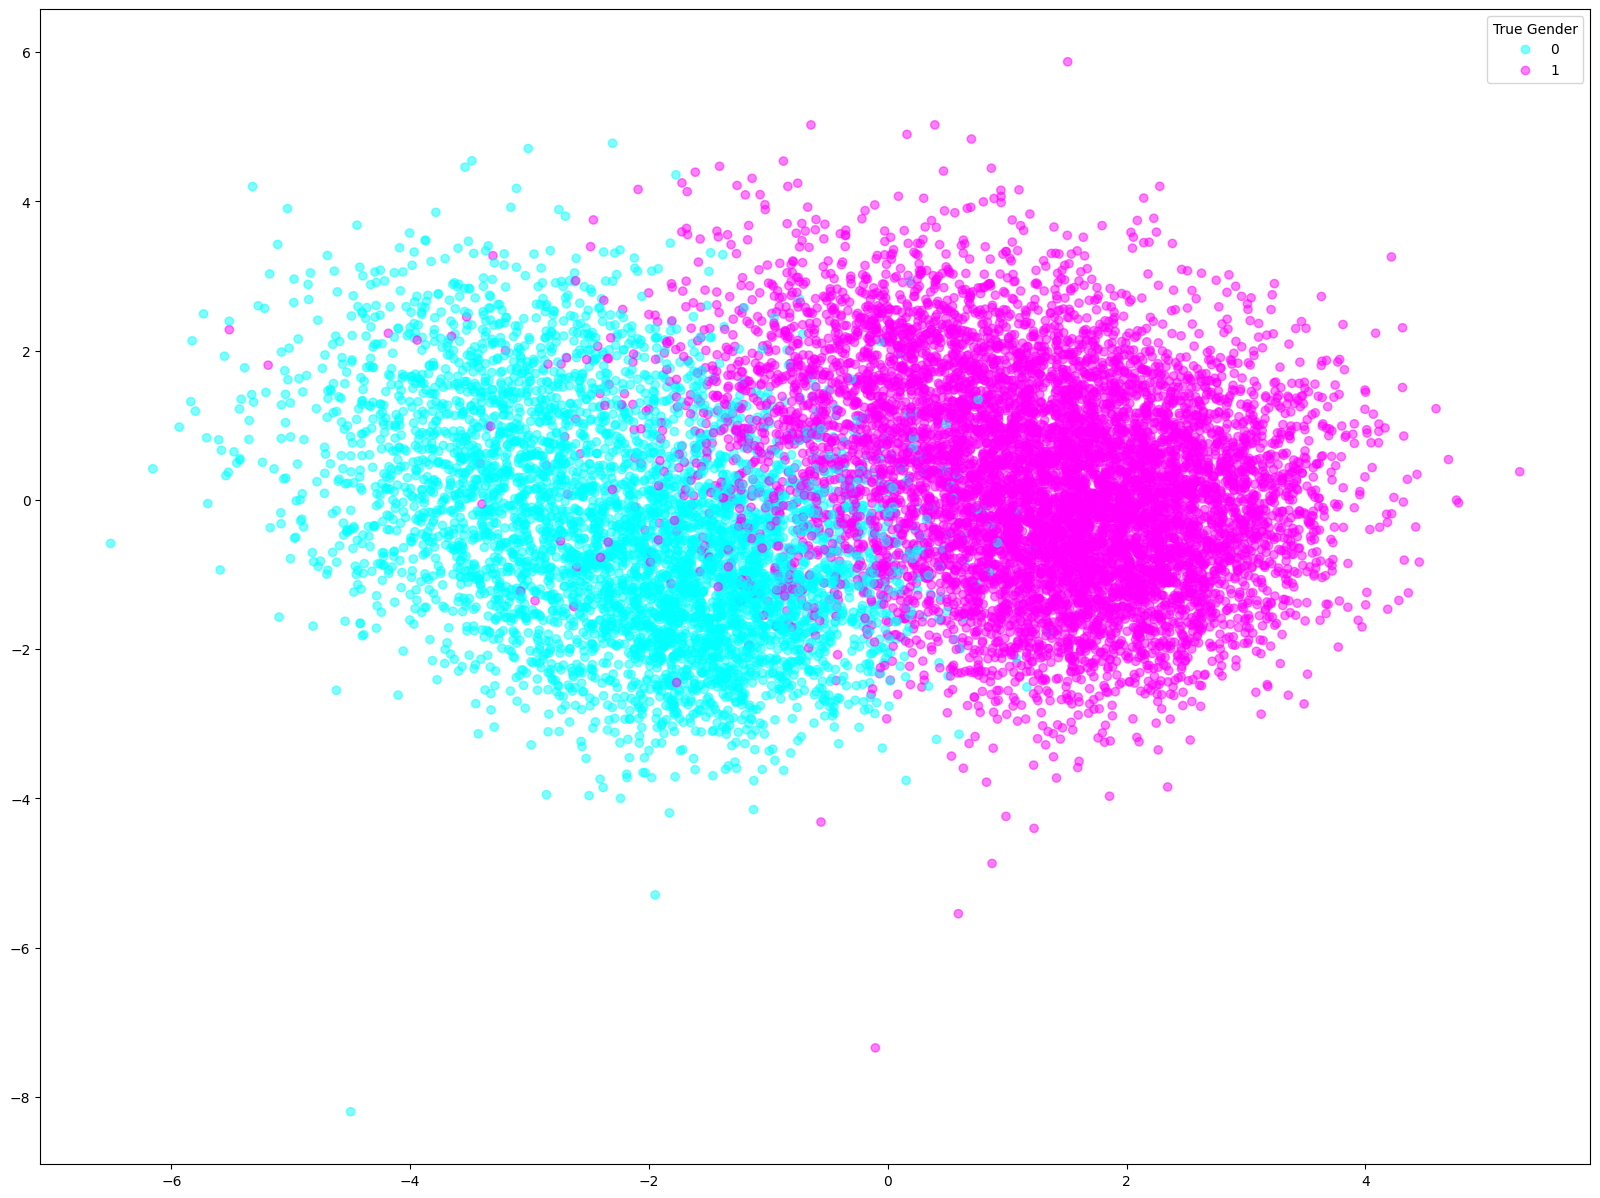

In [52]:
# gender column별 데이터의 분포를 확인
plt.figure(figsize = (20, 15))

sc_class = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c = y2, cmap='cool', alpha = 0.5
)

plt.legend(*sc_class.legend_elements(), title = 'True Gender')
plt.show()